In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import re
import string

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [4]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [5]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
true_df.head()


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
print("Fake Dataset :", fake_df.shape)
print("True Dataset :", true_df.shape)

Fake Dataset : (23481, 4)
True Dataset : (21417, 4)


In [8]:
print(fake_df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [9]:
print(true_df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [10]:
fake_df["label"] = 0
true_df["label"] = 1

In [11]:
news_df = pd.concat([fake_df, true_df], ignore_index=True)

In [12]:
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [13]:
news_df["content"] = news_df["title"] + " " + news_df["text"]

In [14]:
news_df["content"] = news_df["content"].str.lower()

In [15]:
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)

news_df["content"] = news_df["content"].apply(remove_urls)

In [16]:
def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

news_df["content"] = news_df["content"].apply(remove_punctuation)

In [17]:
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

news_df["content"] = news_df["content"].apply(remove_numbers)

In [18]:
news_df["tokens"] = news_df["content"].apply(word_tokenize)

In [19]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

news_df["tokens"] = news_df["tokens"].apply(remove_stopwords)

In [20]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

news_df["tokens"] = news_df["tokens"].apply(lemmatize_tokens)

In [21]:
news_df["clean_text"] = news_df["tokens"].apply(lambda x: " ".join(x))

In [22]:
news_df.to_csv("preprocessed_news.csv", index=False)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [24]:
news_df["clean_text"] = news_df["clean_text"].fillna("")
news_df["clean_text"] = news_df["clean_text"].astype(str)

In [25]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(news_df["clean_text"])

y = news_df["label"]

In [26]:
print(X.shape)
print(y.shape)

(44898, 5000)
(44898,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print(X_train.shape)
print(X_test.shape)

(35918, 5000)
(8980, 5000)


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [30]:
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [31]:
y_pred = rf_model.predict(X_test)

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9973273942093541


In [33]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Precision : 0.9965034965034965
Recall : 0.9978991596638656
F1 Score : 0.9972008397480756


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



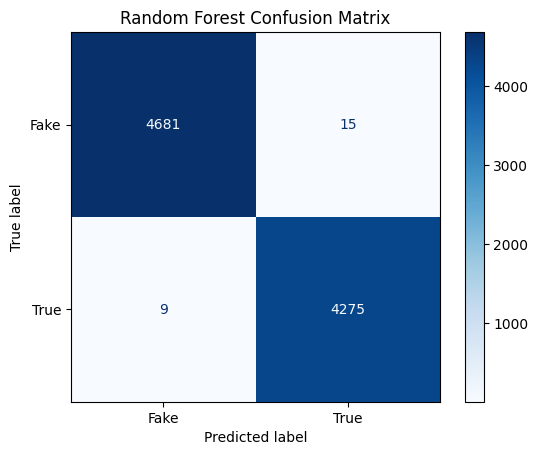

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [36]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

print("Random Forest Model Saved Successfully!")

Random Forest Model Saved Successfully!


In [37]:
joblib.dump(tfidf, "random_forest_tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer Saved Successfully!")

TF-IDF Vectorizer Saved Successfully!
